In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df  = pd.read_csv('https://raw.githubusercontent.com/AkarshVyas/Machine-Learning-Part-1/refs/heads/main/insurance.csv')
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

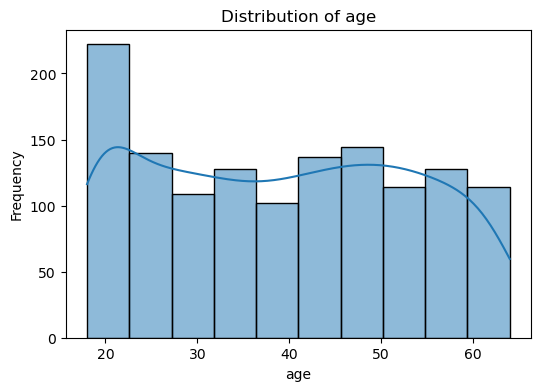

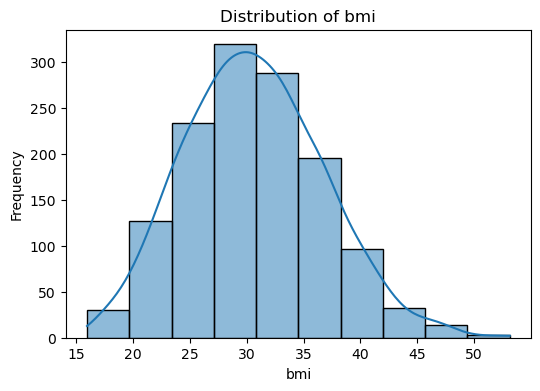

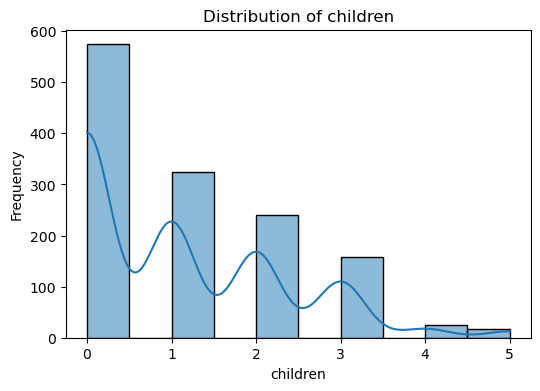

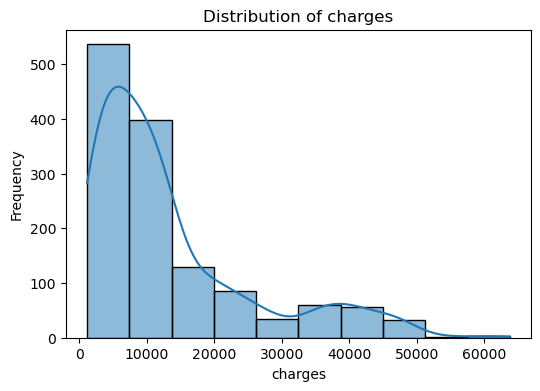

In [7]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[feature], kde=True,bins=10)
    #kde is used to plot the probability density function of a continuous random variable. It is a way to estimate the probability density function of a random variable based on a finite data sample. The KDE plot is a smoothed version of the histogram, which can help to visualize the underlying distribution of the data more clearly.
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [18]:
categorical_features = df.select_dtypes(include=[np.object_]).columns.tolist()
categorical_features

['sex', 'smoker', 'region']

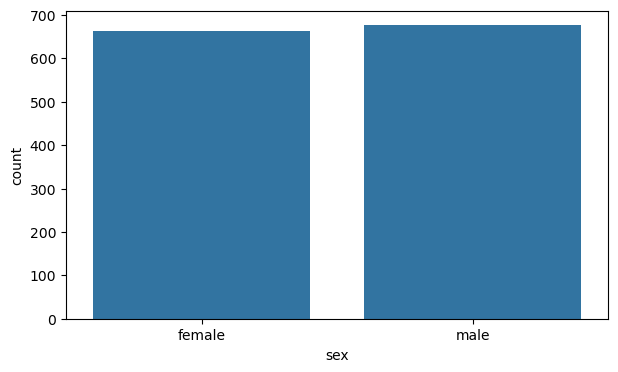

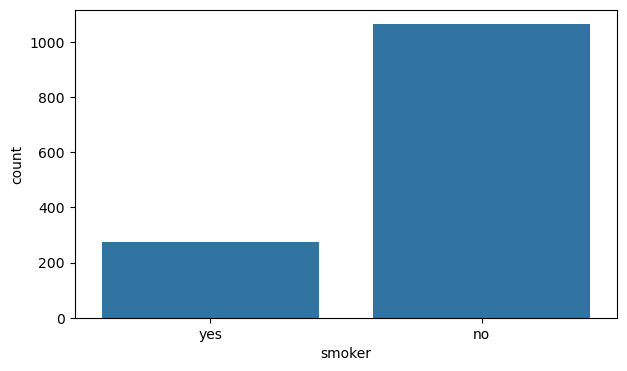

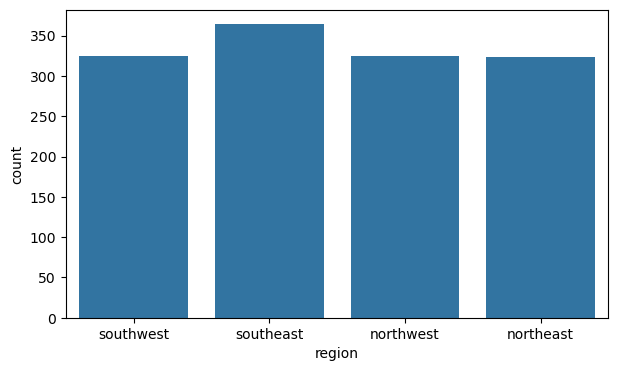

In [25]:
for feature in categorical_features:
    plt.figure(figsize=(7,4))
    sns.countplot(x=df[feature])

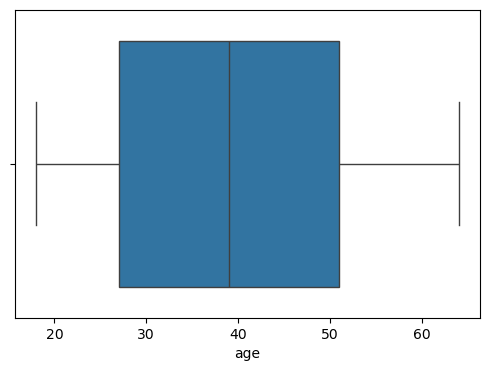

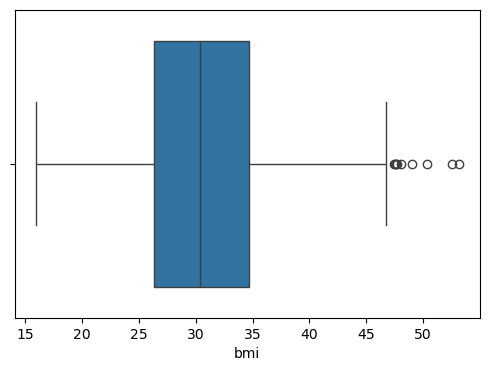

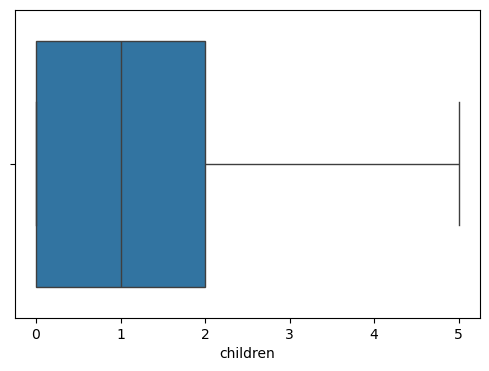

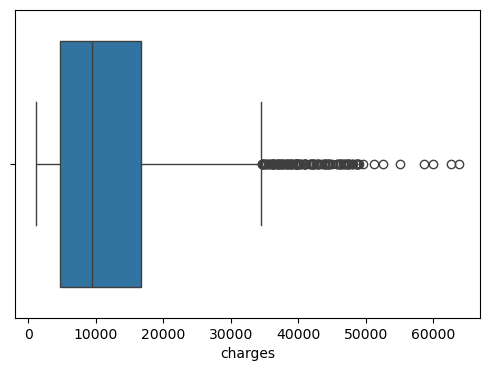

In [ ]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    #this gives us knowledge about outliers
    sns.boxplot(x=df[col])

<Axes: >

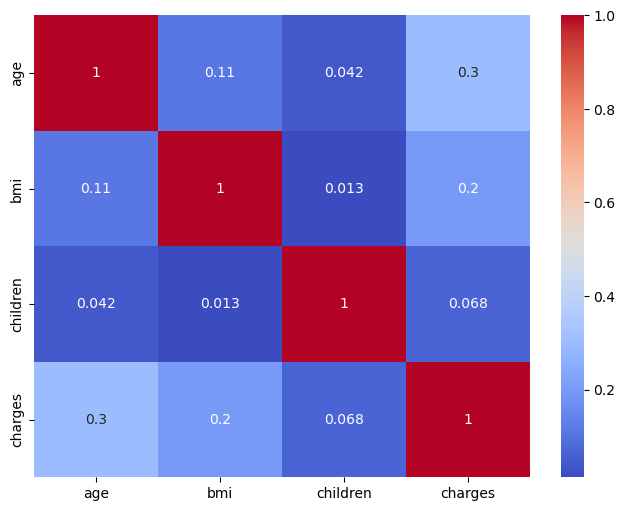

In [ ]:
plt.figure(figsize=(8,6))
#Correlation helps you discover relationships; it doesn't prove why those relationships exist.
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [109]:
df_cleaned=df.copy()


In [93]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [94]:
df_cleaned.shape

(1338, 7)

In [110]:
df_cleaned.drop_duplicates(inplace=True)

In [96]:
df_cleaned.shape

(1337, 7)

In [64]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [111]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})


In [77]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [112]:
df_cleaned.rename(columns={
    'sex':'isFemale',
    'smoker':'isSmoker'
},inplace=True)

In [113]:
#df_cleaned
df_cleaned['isSmoker']=df_cleaned['isSmoker'].map({'yes':1,'no':0})
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [114]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'],drop_first=True)
#drop_True:https://chatgpt.com/s/t_6a91e1ac1c9c8191a98d9a15aa4b59d5
#get_dummies() performs one-hot encoding.
#df_cleaned


In [118]:
df_cleaned['region_northwest'].dtypes

dtype('int64')

In [115]:
df_cleaned = df_cleaned.astype(int)
# feature=['region_northwest', 'region_southeast', 'region_southwest']
# for val in feature:
#     df_cleaned[val]=df_cleaned[val].map({True:1,False:0})

In [119]:
df_cleaned

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1
